# SPbGU AFM U-Net pipeline

Сбор manifest, обучение U-Net, k-fold валидация и экспорт масок/оверлеев для АСМ.

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    """Find repository root from known local path or parent directories."""
    known_roots = [Path(r'D:/Nornikel-2026-Shlif-Case')]
    start = (start or Path.cwd()).resolve()
    markers = [
        Path('configs') / 'segmentation' / 'spbgu_unet.json',
        Path('models') / 'segmentation.py',
    ]
    for candidate in [*known_roots, start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError('Project root not found. Set PROJECT_ROOT manually to D:/Nornikel-2026-Shlif-Case.')


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)


def project_path(value):
    """Resolve relative paths against PROJECT_ROOT."""
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path


D:\Nornikel-2026-Shlif-Case


In [2]:
import torch
from hydra.json_config import JsonConfig

# Options: spbgu_unet.json, spbgu_unet_balanced.json, spbgu_unet_patches.json, spbgu_unet_contours_patches.json
CONFIG_NAME = 'spbgu_unet_contours_patches.json'
CONFIG_PATH = PROJECT_ROOT / 'configs' / 'segmentation' / CONFIG_NAME
cfg = JsonConfig.load(CONFIG_PATH).to_dict()
print('cuda:', torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
cfg

cuda: True
NVIDIA GeForce RTX 3060


{'manifest': {'root': 'spbgu_data',
  'output_csv': 'artifacts/manifests/spbgu_segmentation_manifest.csv',
  'input_kind': 'txt',
  'val_fraction': 0.25,
  'seed': 42},
 'training': {'seed': 42,
  'device': 'auto',
  'dataset_csv': 'artifacts/manifests/spbgu_segmentation_manifest.csv',
  'run_dir': 'notebooks/spbgu_unet_experiments/outputs/runs/spbgu_unet_resnet34_txt_contours_patches',
  'data': {'image_size': 256,
   'patch_size': 256,
   'patch_stride': 128,
   'mask_mode': 'contours',
   'min_patch_foreground': 0.02,
   'max_patch_foreground': 0.98,
   'batch_size': 8,
   'num_workers': 0,
   'augment': True},
  'augmentation': {'hflip_p': 0.5,
   'vflip_p': 0.5,
   'max_rotate_degrees': 0,
   'brightness': 0.12,
   'contrast': 0.2,
   'clahe_p': 0.25,
   'noise_p': 0.2,
   'noise_sigma_min': 0.5,
   'noise_sigma_max': 5.0,
   'blur_p': 0.05,
   'blur_kernel_sizes': [3]},
  'model': {'name': 'smp_unet',
   'encoder_name': 'resnet34',
   'encoder_weights': 'imagenet',
   'in_channel

## Manifest

`input_kind='txt'` обучает на NT-MDT ASCII высотных картах. Для эксперимента с jpg-визуализациями можно поставить `cfg['manifest']['input_kind'] = 'jpg'` и синхронно заменить `training.run_dir`.

In [3]:
import pandas as pd
from data.spbgu_segmentation import SpbguSegmentationManifestBuilder

rows = SpbguSegmentationManifestBuilder(cfg['manifest']).build()
df = pd.DataFrame(rows)
display(df)
display(df.groupby(['subset', 'domain_label']).size())

,sample_id,source_path,mask_path,input_kind,domain_label,rel_path,subset
0,9A003_1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_1.bmp,train
1,9A003_3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_3.bmp,train
2,9A003_7,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_7.bmp,train
3,9A003_9,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A003\9A003_9.bmp,val
4,9A005_1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_1.bmp,val
5,9A005_3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_3.bmp,train
6,9A005_7,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_7.bmp,train
7,9A005_9,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,delivery,сталь 09Г2С\1_Поставка\9A005\9A005_9.bmp,train
8,9S001_1,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,rupture,сталь 09Г2С\6_Разрыв\9S001\9S001_1.bmp,train
9,9S001_3,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,D:\Nornikel-2026-Shlif-Case\spbgu_data\сталь 0...,txt,rupture,сталь 09Г2С\6_Разрыв\9S001\9S001_3.bmp,train


subset  domain_label
train   delivery        6
        rupture         6
val     delivery        2
        rupture         2
dtype: int64

## Sanity check

## Patch Dataset Sanity Check

Проверяем, сколько сэмплов получается после нарезки на патчи.

In [4]:
from data.spbgu_segmentation import SpbguSegmentationDataset, split_rows_by_subset

train_rows = split_rows_by_subset(cfg['training']['dataset_csv'], 'train')
val_rows = split_rows_by_subset(cfg['training']['dataset_csv'], 'val')
train_patch_ds = SpbguSegmentationDataset(
    train_rows,
    image_size=cfg['training']['data']['image_size'],
    augment=False,
    in_channels=cfg['training']['model'].get('in_channels', 3),
    patch_size=cfg['training']['data'].get('patch_size'),
    patch_stride=cfg['training']['data'].get('patch_stride'),
    min_patch_foreground=cfg['training']['data'].get('min_patch_foreground', 0.0),
    max_patch_foreground=cfg['training']['data'].get('max_patch_foreground', 1.0),
    mask_mode=cfg['training']['data'].get('mask_mode', 'foreground'),
)
val_patch_ds = SpbguSegmentationDataset(
    val_rows,
    image_size=cfg['training']['data']['image_size'],
    augment=False,
    in_channels=cfg['training']['model'].get('in_channels', 3),
    patch_size=cfg['training']['data'].get('patch_size'),
    patch_stride=cfg['training']['data'].get('patch_stride'),
    min_patch_foreground=cfg['training']['data'].get('min_patch_foreground', 0.0),
    max_patch_foreground=cfg['training']['data'].get('max_patch_foreground', 1.0),
    mask_mode=cfg['training']['data'].get('mask_mode', 'foreground'),
)
print('source images:', len(train_rows), 'train /', len(val_rows), 'val')
print('patch samples:', len(train_patch_ds), 'train /', len(val_patch_ds), 'val')
display(pd.DataFrame(train_patch_ds.samples).patch_foreground.astype(float).describe() if train_patch_ds.samples and 'patch_foreground' in train_patch_ds.samples[0] else 'full-image mode')


source images: 12 train / 4 val
patch samples: 108 train / 36 val


count    108.000000
mean       0.333190
std        0.073357
min        0.165558
25%        0.291077
50%        0.331016
75%        0.385242
max        0.512680
Name: patch_foreground, dtype: float64

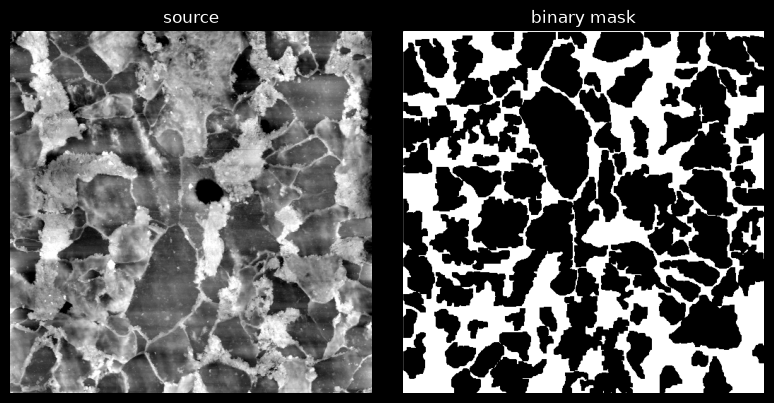

In [5]:
import matplotlib.pyplot as plt
from data.spbgu_segmentation import read_spbgu_binary_mask, read_spbgu_image

sample = df.iloc[0]
image = read_spbgu_image(sample.source_path, sample.input_kind)
mask = read_spbgu_binary_mask(sample.mask_path, cfg['training']['data'].get('mask_mode', 'foreground'))
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('source')
axes[1].imshow(mask, cmap='gray')
axes[1].set_title('binary mask')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

## Holdout training

In [6]:
from trainers.spbgu_unet_trainer import SpbguUNetTrainer

trainer = SpbguUNetTrainer(cfg['training'])
summary = trainer.fit()
summary

spbgu epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

train spbgu 1:   0%|          | 0/14 [00:00<?, ?batch/s]

val spbgu 1:   0%|          | 0/5 [00:00<?, ?batch/s]

train spbgu 2:   0%|          | 0/14 [00:00<?, ?batch/s]

val spbgu 2:   0%|          | 0/5 [00:00<?, ?batch/s]

...

train spbgu 16:   0%|          | 0/14 [00:00<?, ?batch/s]

val spbgu 16:   0%|          | 0/5 [00:00<?, ?batch/s]

train spbgu 17:   0%|          | 0/14 [00:00<?, ?batch/s]

val spbgu 17:   0%|          | 0/5 [00:00<?, ?batch/s]

{'best_val_score': 0.2714058988624149, 'epochs': 17}

dice                 0.419572
f1                   0.419572
iou                  0.271406
precision            0.299207
recall               0.746176
mask_fraction_mae    0.451224
loss                 0.638183
roc_auc              0.498534
dtype: float64

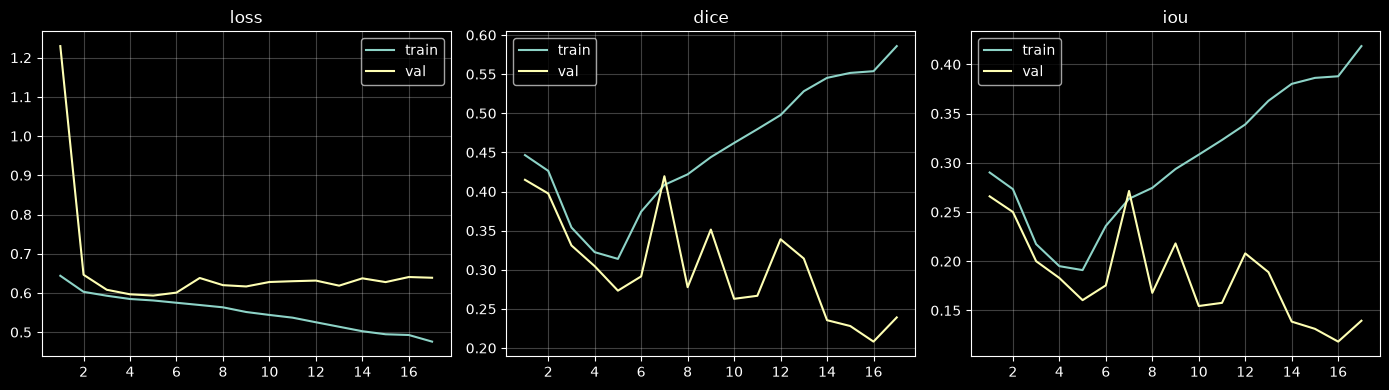

In [7]:
run_dir = project_path(cfg['training']['run_dir'])
history = pd.read_csv(run_dir / 'history.csv')
display(pd.read_json(run_dir / 'best_metrics.json', typ='series'))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(history.epoch, history.train_loss, label='train')
axes[0].plot(history.epoch, history.val_loss, label='val')
axes[0].set_title('loss')
axes[1].plot(history.epoch, history.train_dice, label='train')
axes[1].plot(history.epoch, history.val_dice, label='val')
axes[1].set_title('dice')
axes[2].plot(history.epoch, history.train_iou, label='train')
axes[2].plot(history.epoch, history.val_iou, label='val')
axes[2].set_title('iou')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()

## Threshold and Baseline Analysis

Эта ячейка проверяет, не является ли высокий Dice следствием почти полной заливки foreground. Сравниваем модель с baseline `all foreground` и подбираем порог по IoU.

val target fraction: [0.6458 0.7449 0.6971 0.663 ] mean= 0.6877
val prob fraction: [0.6202 0.5219 0.6008 0.6517] mean= 0.5987
all-foreground baseline: {'dice': 0.8144, 'iou': 0.6877, 'precision': 0.6877, 'recall': 1.0, 'mask_fraction_mae': 0.3123}


,threshold,dice,iou,precision,recall,mask_fraction_mae
4,0.25,0.814416,0.687779,0.687821,0.999923,0.312061
3,0.20,0.814374,0.687714,0.687714,1.000000,0.312283
0,0.05,0.814366,0.687702,0.687702,1.000000,0.312298
2,0.15,0.814366,0.687702,0.687702,1.000000,0.312298
1,0.10,0.814366,0.687702,0.687702,1.000000,0.312298
5,0.30,0.813367,0.686186,0.687635,0.997394,0.309780
6,0.35,0.810041,0.681227,0.687002,0.989509,0.302704
7,0.40,0.805472,0.674623,0.687530,0.976136,0.288559


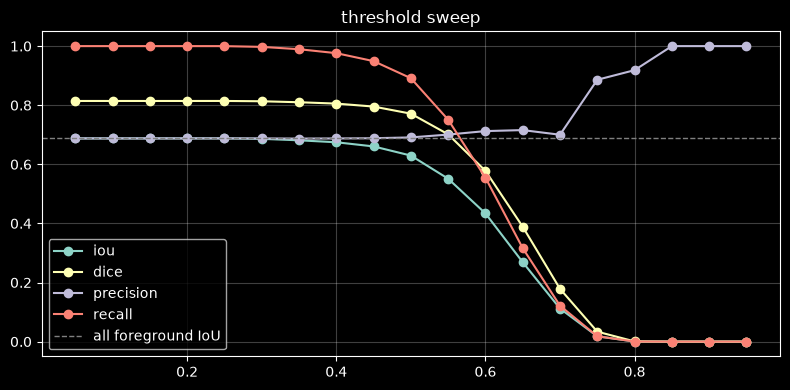

In [8]:
import numpy as np
from torch.utils.data import DataLoader

from data.spbgu_segmentation import SpbguSegmentationDataset, split_rows_by_subset
from models.segmentation import SegmentationFactory

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint = torch.load(run_dir / 'best.pt', map_location=device)
model = SegmentationFactory.create(checkpoint['config']['model']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

val_rows = split_rows_by_subset(cfg['training']['dataset_csv'], 'val')
val_dataset = SpbguSegmentationDataset(
    val_rows,
    image_size=cfg['training']['data']['image_size'],
    augment=False,
    in_channels=cfg['training']['model'].get('in_channels', 3),
)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

prob_chunks, target_chunks = [], []
with torch.no_grad():
    for batch in val_loader:
        logits = model(batch['image'].to(device))
        prob_chunks.append(torch.sigmoid(logits).cpu().numpy())
        target_chunks.append(batch['mask'].numpy())

probs = np.concatenate(prob_chunks, axis=0)
targets = np.concatenate(target_chunks, axis=0)
target_fraction = targets.mean(axis=(1, 2, 3))
prob_fraction = probs.mean(axis=(1, 2, 3))

def binary_metrics(pred, target):
    tp = (pred * target).sum(axis=(1, 2, 3))
    fp = (pred * (1 - target)).sum(axis=(1, 2, 3))
    fn = ((1 - pred) * target).sum(axis=(1, 2, 3))
    dice = np.mean((2 * tp + 1e-7) / (2 * tp + fp + fn + 1e-7))
    iou = np.mean((tp + 1e-7) / (tp + fp + fn + 1e-7))
    precision = np.mean((tp + 1e-7) / (tp + fp + 1e-7))
    recall = np.mean((tp + 1e-7) / (tp + fn + 1e-7))
    fraction_mae = np.mean(np.abs(pred.mean(axis=(1, 2, 3)) - target.mean(axis=(1, 2, 3))))
    return {'dice': dice, 'iou': iou, 'precision': precision, 'recall': recall, 'mask_fraction_mae': fraction_mae}

all_fg = binary_metrics(np.ones_like(targets, dtype=np.float32), targets)
print('val target fraction:', np.round(target_fraction, 4), 'mean=', round(float(target_fraction.mean()), 4))
print('val prob fraction:', np.round(prob_fraction, 4), 'mean=', round(float(prob_fraction.mean()), 4))
print('all-foreground baseline:', {k: round(float(v), 4) for k, v in all_fg.items()})

sweep_rows = []
for threshold in np.linspace(0.05, 0.95, 19):
    metrics = binary_metrics((probs >= threshold).astype(np.float32), targets)
    sweep_rows.append({'threshold': threshold, **metrics})
threshold_df = pd.DataFrame(sweep_rows)
display(threshold_df.sort_values('iou', ascending=False).head(8))

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ['iou', 'dice', 'precision', 'recall']:
    ax.plot(threshold_df.threshold, threshold_df[metric], marker='o', label=metric)
ax.axhline(all_fg['iou'], color='gray', linestyle='--', linewidth=1, label='all foreground IoU')
ax.grid(alpha=0.25)
ax.legend()
ax.set_title('threshold sweep')
plt.tight_layout()


## Validation Predictions Preview

Сохраняем и показываем несколько примеров: исходная АСМ-карта, GT, probability map, бинарное предсказание и overlay.

D:\Nornikel-2026-Shlif-Case\notebooks\spbgu_unet_experiments\outputs\prediction_previews\val_predictions_preview.png


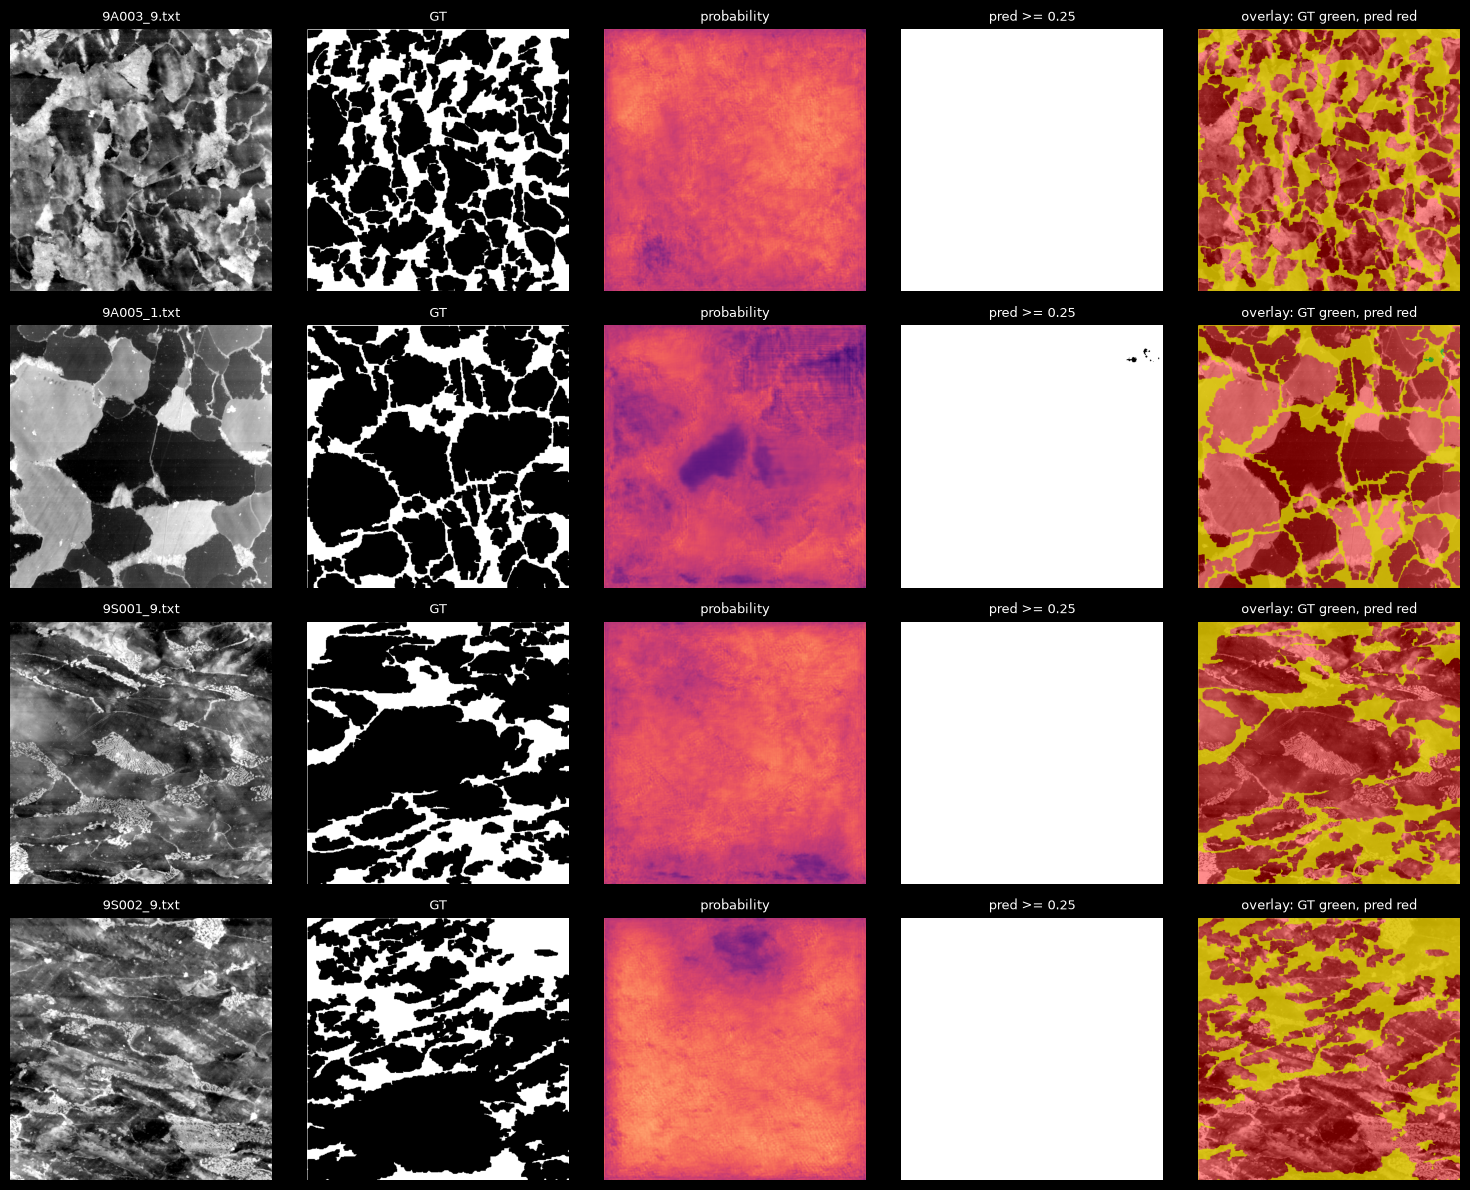

In [9]:
import cv2
from PIL import Image

from data.spbgu_segmentation import read_spbgu_binary_mask, read_spbgu_image
from visualization.spbgu_segmentation import SpbguMaskPredictor

PREVIEW_DIR = project_path('notebooks/spbgu_unet_experiments/outputs/prediction_previews')
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

threshold = float(threshold_df.sort_values('iou', ascending=False).iloc[0].threshold) if 'threshold_df' in globals() else cfg['prediction']['threshold']
predictor = SpbguMaskPredictor(run_dir / 'best.pt')
preview_rows = val_rows[: min(6, len(val_rows))]

fig, axes = plt.subplots(len(preview_rows), 5, figsize=(15, 3 * len(preview_rows)))
if len(preview_rows) == 1:
    axes = axes[None, :]

for row_idx, row in enumerate(preview_rows):
    prob, source_image = predictor.predict_image(row['source_path'], row.get('input_kind', 'txt'))
    gt = np.asarray(read_spbgu_binary_mask(row['mask_path'], cfg['training']['data'].get('mask_mode', 'foreground'))) > 0
    pred = prob >= threshold
    source = np.asarray(source_image.convert('RGB'))
    if gt.shape[:2] != source.shape[:2]:
        gt = cv2.resize(gt.astype(np.uint8), (source.shape[1], source.shape[0]), interpolation=cv2.INTER_NEAREST).astype(bool)
    overlay = source.astype(np.float32).copy()
    overlay[gt] = 0.55 * overlay[gt] + 0.45 * np.array([0, 255, 0], dtype=np.float32)
    overlay[pred] = 0.55 * overlay[pred] + 0.45 * np.array([255, 0, 0], dtype=np.float32)
    both = gt & pred
    overlay[both] = 0.45 * overlay[both] + 0.55 * np.array([255, 255, 0], dtype=np.float32)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    panels = [source, gt, prob, pred, overlay]
    titles = [Path(row['source_path']).name, 'GT', 'probability', f'pred >= {threshold:.2f}', 'overlay: GT green, pred red']
    for col_idx, (panel, title) in enumerate(zip(panels, titles)):
        ax = axes[row_idx, col_idx]
        if panel.dtype == bool:
            ax.imshow(panel, cmap='gray', vmin=0, vmax=1)
        elif panel.ndim == 2:
            ax.imshow(panel, cmap='magma', vmin=0, vmax=1)
        else:
            ax.imshow(panel)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

plt.tight_layout()
preview_path = PREVIEW_DIR / 'val_predictions_preview.png'
fig.savefig(preview_path, dpi=160, bbox_inches='tight')
print(preview_path)


## Prediction overlays

In [10]:
from visualization.spbgu_segmentation import SpbguMaskPredictor

predictor = SpbguMaskPredictor(run_dir / 'best.pt')
predictor.save_manifest_predictions(
    cfg['prediction']['manifest_csv'],
    cfg['prediction']['output_dir'],
    threshold=cfg['prediction']['threshold'],
)
print(project_path(cfg['prediction']['output_dir']))

D:\Nornikel-2026-Shlif-Case\notebooks\spbgu_unet_experiments\outputs\predictions\spbgu_unet_resnet34_txt_contours_patches


## Cross-validation

Запускай после holdout, если нужно подтвердить устойчивость модели. На текущем SPbGU наборе по умолчанию 4 fold, потому что грубых доменных групп всего две и данных мало.

In [11]:
RUN_CV = False
if RUN_CV:
    from trainers.spbgu_unet_trainer import SpbguCrossValidator
    cv_result = SpbguCrossValidator(cfg['training']).run()
    print(cv_result)
    cv_dir = Path(cv_result['run_dir'])
    display(pd.read_csv(cv_dir / 'cv_metrics.csv'))
    display(pd.read_json(cv_dir / 'cv_summary.json').T)